# IMPORT n Download

## Data Loading

This cell loads the crypto market data and organizes it by timeframe.

`load_data()` returns a dictionary of OHLCV panels already resampled at multiple frequencies, together with the list of available assets. We then extract three datasets:
- `h1_data` for 1-hour bars
- `h4_data` for 4-hour bars
- `daily_data` for 1-day bars

These panel datasets are the raw market inputs used downstream for indicator construction, signal generation, target definition, and model training.


In [1]:
from download import (
    load_data,
    load_indicator_mapping,
)

from features import (
    compute_all_indicators
)

from preprocessing import (
    add_all_signal_features,
    build_default_indicator_family_map,
    get_added_signal_columns,
    build_regression_dataset, 
    validate_regression_dataset

)

from target import (
    add_targets_for_multiple_horizons, 
    validate_target_alignment

)

from modele import (
    temporal_train_val_test_split, 
    summarize_temporal_split,
    temporal_train_val_test_split,
    train_validate_penalized_logit_grid,
    fit_penalized_logit,
    score_penalized_logit,
    extract_penalized_logit_coefficients,
    evaluate_top_k_hit_rate,
    run_penalized_logistic_rolling_backtest
    
)
from vis import (
    plot_confusion_matrix_for_backtest,
)

from modele_rf import (
    fit_random_forest_classifier,
    score_random_forest_classifier,
    train_validate_random_forest_grid,
    extract_random_forest_feature_importance,
    run_random_forest_rolling_backtest,
    evaluate_top_k_hit_rate,
)


import pandas as pd
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, brier_score_loss


pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

data, assets = load_data()
h1_data = data["1H"]
h4_data = data["4H"]
daily_data = data["1D"]

Donnees crypto chargees: 56 assets | timeframes: 1H, 4H, 1D


## Indicator Metadata

This cell loads the indicator metadata table.

`load_indicator_mapping()` imports the indicator reference file, which links each indicator to its signal family and natural direction. This mapping is used later to organize features consistently across the pipeline and to assign family-specific signal construction rules.


In [2]:
indicator_mapping = load_indicator_mapping()


Mapping indicateurs charge: 71 lignes depuis level2_indicator_mapping_model_ready_v2.csv


# Features enginerening 

## Technical Indicator Computation

This cell computes the full technical indicator set on the daily panel.

`compute_all_indicators(daily_data)` transforms the raw OHLCV data into a broad feature matrix of technical indicators, covering trend, momentum, volatility, band/channel, and volume-based measures. The output is a panel of engineered features aligned by date and asset, ready for signal construction.


In [3]:
features = compute_all_indicators(daily_data)

Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : les features VIX sont remplies avec NaN.
Colonne `vix` absente : l

## Family-Specific Signal Engineering

This block converts raw indicator values into a standardized signal representation usable in cross-sectional ML.

We first build `indicator_family_map`, which assigns each feature column to a signal family. We then apply `add_all_signal_features(...)`, which creates four core signal variables for every eligible feature:
- `signal_direction`
- `signal_active`
- `signal_strength`
- `signal_signed_value`

The transformation is family-specific and follows the explicit rules implemented in `preprocessing.py`.

  1. Centered Oscillators

This family includes indicators naturally centered around zero, such as MACD, PPO, ROC, APO, momentum, KST, BOP, and similar oscillators.

For a raw feature `X(i,t)`:
- `signal_direction = sign(X(i,t))`
- we compute a cross-sectional **leave-one-out z-score** at each date `t`, across assets:
  `z_loo(i,t) = [X(i,t) - mu_loo(i,t)] / sigma_loo(i,t)`
- `signal_active = 1` if `abs(z_loo(i,t)) > 2.0`, else `0`
- `signal_strength = abs(z_loo(i,t))`
- `signal_signed_value = z_loo(i,t)`

So activation captures whether the oscillator is unusually extreme relative to the cross-section at that date, not just whether it is positive or negative.

   2. Extreme-Zone Oscillators

This family covers bounded or range-based oscillators such as RSI, RSX, Stochastic, MFI, CCI, PGO, COG, and the emotion / willingness proxies.

Each feature is assigned explicit bounds, for example:
- RSI / RSX / Stochastic / MFI: `[0, 100]`
- CCI: `[-200, 200]`
- PGO: `[-3, 3]`
- COG: `[-10, 10]`

For a bounded feature `X(i,t)`:
- values are clipped to the configured interval if needed
- the midpoint is:
  `m = (lower_bound + upper_bound) / 2`
- `signal_direction = +1` in the lower half, `-1` in the upper half
- `signal_active = 1` if the raw value is valid and lies inside the configured interval
- `signal_strength = abs(X_clipped(i,t) - m)`
- a signed force is defined as:
  `signed_force(i,t) = m - X_clipped(i,t)`
  so it is positive in the lower half and negative in the upper half
- `signal_signed_value` is the cross-sectional leave-one-out z-score of `signed_force(i,t)`

Hence, this family combines within-range location with cross-sectional standardization of how extreme that location is across assets.

   3. Trend Filters

This family includes features such as moving-average spreads, Aroon-style trend measures, Ichimoku trend features, linear-regression trend slopes, PSAR distance, and similar directional state variables.

For each feature `X(i,t)`, the signal is built from its time-series change:
`delta_X(i,t) = X(i,t) - X(i,t-1)`

Then:
- we compute the cross-sectional leave-one-out z-score of `delta_X(i,t)`
- this z-score is the **trend score**
- `signal_direction = sign(trend_score)`
- `signal_active = 1` if `abs(trend_score) > 2.0`
- `signal_strength = abs(trend_score)`
- `signal_signed_value = trend_score`

This means the model does not directly use the level of the trend filter as signal state, but rather whether the trend measure is strengthening or weakening relative to the cross-section.

   4. Volume Confirmation Indicators

This family includes OBV, PVT, CMF, accumulation/distribution features, and similar volume-confirmation measures.

The logic is also based on first differences:
`delta_X(i,t) = X(i,t) - X(i,t-1)`

Then:
- `signal_direction = sign(delta_X(i,t))`
- we compute the cross-sectional leave-one-out z-score of `delta_X(i,t)`
- this z-score acts as a **variance / abnormality score**
- `signal_active = 1` if `abs(z_loo(i,t)) > 2.0`
- `signal_strength = abs(z_loo(i,t))`
- `signal_signed_value = z_loo(i,t)`

So the signal captures whether the recent change in a volume-confirmation feature is unusually large relative to the asset cross-section.

  5. Band / Channel / Level Signals

This family is only explicitly implemented for **Bollinger Bands** at this stage.

The signal is built from:
- the reference price, by default `close`
- `bb_upper_*`
- `bb_lower_*`
- the corresponding Bollinger feature

For each date and asset:
- `signal_direction = +1` if price is above the upper band
- `signal_direction = -1` if price is below the lower band
- `signal_direction = 0` if price is inside the band

Distance to the nearest violated band is then computed:
- above upper band: `price - upper`
- below lower band: `lower - price`
- inside band: `0`

Then:
- a cross-sectional leave-one-out dispersion is computed on that distance
- `band_score = distance / cs_std_loo`
- `signal_active = 1` if price is outside the band and `band_score > 2.0`
- `signal_strength = abs(band_score)`
- `signal_signed_value = signal_direction * abs(band_score)`

So activation only occurs when the band break is both directional and unusually large cross-sectionally.

   6. Context Filters

Indicators in the `context_filter` family are **not converted into directional signals**. They are kept as contextual state variables and later enter the regression dataset as common explanatory features at the `date x asset` level.

This includes variables such as ATR, ADX, choppiness, entropy, kurtosis, midpoint / midprice, quantile rank, and related non-directional market-state descriptors.

  Output

Finally, `get_added_signal_columns(signals)` returns the full list of generated signal columns. This is useful for auditing which transformed signal variables were created and passed downstream into target construction and model estimation.


In [4]:
indicator_family_map = build_default_indicator_family_map(features)

signals = add_all_signal_features(
    features,
    indicator_family_map=indicator_family_map,
)

added_cols = get_added_signal_columns(signals)
print(added_cols)


['apo_12_26__signal_direction', 'apo_12_26__signal_active', 'apo_12_26__signal_strength', 'apo_12_26__signal_signed_value', 'apo_12_26__cs_mean_loo', 'apo_12_26__cs_std_loo', 'apo_12_26__cs_zscore_loo', 'ado_3_10__signal_direction', 'ado_3_10__signal_active', 'ado_3_10__signal_strength', 'ado_3_10__signal_signed_value', 'ado_3_10__cs_mean_loo', 'ado_3_10__cs_std_loo', 'ado_3_10__cs_zscore_loo', 'awesome_oscillator_5_34__signal_direction', 'awesome_oscillator_5_34__signal_active', 'awesome_oscillator_5_34__signal_strength', 'awesome_oscillator_5_34__signal_signed_value', 'awesome_oscillator_5_34__cs_mean_loo', 'awesome_oscillator_5_34__cs_std_loo', 'awesome_oscillator_5_34__cs_zscore_loo', 'bop__signal_direction', 'bop__signal_active', 'bop__signal_strength', 'bop__signal_signed_value', 'bop__cs_mean_loo', 'bop__cs_std_loo', 'bop__cs_zscore_loo', 'bias_20__signal_direction', 'bias_20__signal_active', 'bias_20__signal_strength', 'bias_20__signal_signed_value', 'bias_20__cs_mean_loo', 'bi

## Target Construction Across Multiple Horizons

This step builds the supervised learning targets from the signal panel.

`add_targets_for_multiple_horizons(...)` creates horizon-specific future-return targets for each signal feature, using three forecast horizons:
- `1d`
- `4d`
- `24d`

For each asset, date, indicator, and horizon:
- the signal is observed at date `t`
- the future return is computed from `t` to `t+h`
- the target remains attached to the row at date `t`

The target is built using:
- `target_scaling="cross_sectional_future_return"`
- `tau=0`

This means the raw future return is first standardized cross-sectionally at each date and horizon:
- compute `future_return(i,t,h)`
- compute the cross-sectional standard deviation across assets at the same `t` and `h`
- define `future_return_cs_scaled(i,t,h) = future_return(i,t,h) / sigma_cs(t,h)`

The binary target is then:
- `target = 1` if `signal_direction(i,t) * future_return_cs_scaled(i,t,h) > 0`
- `target = 0` otherwise

So with `tau=0`, a signal is labeled successful whenever its direction matches the sign of the cross-sectionally scaled future move.

Additional settings:
- `inactive_policy="nan"`:
  rows where `signal_active = 0` are not forced into class `0`; their target is set to missing and can be excluded later
- `min_cs_assets=3`:
  at least three valid assets are required to compute a cross-sectional dispersion
- `min_cs_std=1e-12`:
  protects against degenerate cross-sectional volatility when scaling future returns

This step is critical because it defines the prediction problem consistently across horizons while preserving the correct temporal alignment between signal date and realized forward performance.

In [5]:
targets = add_targets_for_multiple_horizons(
    signals,
    horizons={"1d": 1, "4d": 4, "24d": 24},
    signal_columns=None,
    price_col="close",
    asset_col="asset",
    datetime_col="date",
    target_scaling="cross_sectional_future_return",
    tau=0,
    inactive_policy="nan",
    min_cs_assets=3,
    min_cs_std=1e-12,
)

/Users/adrienferrand-bastet/Desktop/RESEARCH/target.py:796: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[target_col] = _compute_binary_target(
/Users/adrienferrand-bastet/Desktop/RESEARCH/target.py:796: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[target_col] = _compute_binary_target(
/Users/adrienferrand-bastet/Desktop/RESEARCH/target.py:796: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

## Final Regression Dataset

This step converts the wide signal panel into the final long-format supervised dataset used for modeling.

`build_regression_dataset(...)` reshapes the data so that each row corresponds to a unique:
`date x asset x indicator_name x horizon`

Each observation contains:
- the indicator identity (`indicator_name`)
- its family (`signal_family`)
- the signal variables:
  - `signal_direction`
  - `signal_active`
  - `signal_strength`
  - `signal_signed_value`
- the corresponding horizon-specific `target`
- the asset-date context features from the `context_filter` family

With:
- `include_inactive=False`, only active signals are kept
- `drop_missing_target=True`, rows without valid targets are removed
- `exclude_vix_context=True`, VIX-related context variables are excluded

This is the key reshape that turns the engineered panel into a model-ready classification dataset.

`validate_regression_dataset(...)` then checks that the result is structurally sound:
- required columns are present
- there are no duplicates on `date, asset, indicator_name, horizon`
- the number of rows, assets, indicators, horizons, and context features is coherent

At this point, `regression_df` is the final dataset used for logistic regression and random forest benchmarking.


In [ ]:
regression_df = build_regression_dataset(
    targets,
    asset_col="asset",
    datetime_col="date",
    include_inactive=False,
    drop_missing_target=True,
    exclude_vix_context=True,
)

summary = validate_regression_dataset(
    regression_df,
    asset_col="asset",
    datetime_col="date",
)

print(regression_df.shape)
print(regression_df.columns.tolist())
print(summary)

Validation regression dataset
- rows: 2835593
- assets: 56
- datetimes: 2068
- indicators: 62
- horizons: 3
- context features: 19
- target NaN: 0
- duplicates(date, asset, indicator, horizon): 0
(2835593, 29)
['date', 'asset', 'indicator_name', 'signal_family', 'horizon', 'signal_direction', 'signal_active', 'signal_strength', 'signal_signed_value', 'target', 'hlc_average', 'median_price', 'ohlc_average', 'atr_14', 'natr_14', 'adx_14', 'plus_di_14', 'minus_di_14', 'dx_14', 'choppiness_14', 'entropy_20', 'kurtosis_20', 'mass_index_9_25', 'mad_close_20', 'midpoint_14', 'midprice_14', 'price_distance_sma_20', 'price_distance_ref_sma_20', 'quantile_rank_20']
{'num_rows': 2835593, 'num_assets': 56, 'num_datetimes': 2068, 'num_indicators': 62, 'num_horizons': 3, 'num_context_features': 19, 'duplicate_count': 0, 'target_nan_count': 0, 'active_row_count': 2835593, 'inactive_row_count': 0, 'is_valid': True}


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20
0,2019-12-19,BCHUSDT,bop,centered_oscillator,1d,1.0,1.0,5.770883,5.770883,1.0,186.18,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-12-19,BCHUSDT,bop,centered_oscillator,24d,1.0,1.0,5.770883,5.770883,1.0,186.18,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-12-19,BCHUSDT,bop,centered_oscillator,4d,1.0,1.0,5.770883,5.770883,1.0,186.18,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-12-19,BTCUSDT,cci_20,extreme_zone_oscillator,1d,1.0,1.0,31.055144,NaN,1.0,7185.66,7205.345,7208.7725,369.399327,0.051691,23.640399,18.386114,21.908692,8.742016,46.874504,0.556033,7.497875,24.246032,157.4249,7070.53,7051.74,-0.013789,7246.211,0.25
4,2019-12-19,BTCUSDT,cci_20,extreme_zone_oscillator,24d,1.0,1.0,31.055144,NaN,1.0,7185.66,7205.345,7208.7725,369.399327,0.051691,23.640399,18.386114,21.908692,8.742016,46.874504,0.556033,7.497875,24.246032,157.4249,7070.53,7051.74,-0.013789,7246.211,0.25


In [7]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(regression_df)


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20
0,2019-12-19,BCHUSDT,bop,centered_oscillator,1d,1.0,1.0,5.770883,5.770883,1.0,186.180000,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-12-19,BCHUSDT,bop,centered_oscillator,24d,1.0,1.0,5.770883,5.770883,1.0,186.180000,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-12-19,BCHUSDT,bop,centered_oscillator,4d,1.0,1.0,5.770883,5.770883,1.0,186.180000,186.200,185.8850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-12-19,BTCUSDT,cci_20,extreme_zone_oscillator,1d,1.0,1.0,31.055144,NaN,1.0,7185.660000,7205.345,7208.7725,369.399327,0.051691,23.640399,18.386114,21.908692,8.742016,46.874504,0.556033,7.497875,24.246032,157.4249,7070.53,7051.740,-0.013789,7246.211,0.25
4,2019-12-19,BTCUSDT,cci_20,extreme_zone_oscillator,24d,1.0,1.0,31.055144,NaN,1.0,7185.660000,7205.345,7208.7725,369.399327,0.051691,23.640399,18.386114,21.908692,8.742016,46.874504,0.556033,7.497875,24.246032,157.4249,7070.53,7051.740,-0.013789,7246.211,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2835588,2025-08-16,ZECUSDT,rsi_14,extreme_zone_oscillator,1d,1.0,1.0,6.702096,2.303848,1.0,36.593333,36.535,36.5375,2.511330,0.068410,14.005892,14.939435,21.142009,17.190481,63.681141,0.612602,-0.034958,24.578273,1.5182,37.53,37.855,-0.025277,37.662,0.45
2835589,2025-08-16,ZECUSDT,rsx_14,extreme_zone_oscillator,1d,1.0,1.0,11.051757,2.444696,1.0,36.593333,36.535,36.5375,2.511330,0.068410,14.005892,14.939435,21.142009,17.190481,63.681141,0.612602,-0.034958,24.578273,1.5182,37.53,37.855,-0.025277,37.662,0.45
2835590,2025-08-16,ZECUSDT,stochastic_d_14_3,extreme_zone_oscillator,1d,1.0,1.0,18.986627,2.891087,1.0,36.593333,36.535,36.5375,2.511330,0.068410,14.005892,14.939435,21.142009,17.190481,63.681141,0.612602,-0.034958,24.578273,1.5182,37.53,37.855,-0.025277,37.662,0.45
2835591,2025-08-16,ZECUSDT,stochastic_k_14_3,extreme_zone_oscillator,1d,1.0,1.0,18.678630,3.195188,1.0,36.593333,36.535,36.5375,2.511330,0.068410,14.005892,14.939435,21.142009,17.190481,63.681141,0.612602,-0.034958,24.578273,1.5182,37.53,37.855,-0.025277,37.662,0.45


# Modele 

## Penalized Logistic Regression 

### Penalized Logistic Regression with classical standardisation 

The penalized logistic regression model is used as a cross-sectional benchmark to estimate whether a given technical indicator is likely to generate a successful signal for a specific crypto asset, at a specific date, and for a specific forecast horizon. The final modeling dataset is built in long format, so each row corresponds to one `date × asset × indicator_name × horizon` observation with a binary target.

A separate model is trained for each horizon (`1d`, `4d`, `24d`) because the prediction problem changes materially with the holding period: short-horizon and longer-horizon signal dynamics are not expected to share the same structure. The model takes as inputs the signal features derived from each indicator, together with contextual market-state variables, and is evaluated under a rolling-window backtest with embargo to preserve temporal integrity.

In this implementation, the model uses **classical standardization** for numerical inputs. Concretely, numerical features are scaled with a `StandardScaler` fitted **only on the training fold** inside the sklearn pipeline, and then applied unchanged to the corresponding out-of-sample test fold. This avoids leakage while keeping the logistic coefficients numerically stable and comparable across folds.

Its most important output is not the binary class itself, but the estimated `pred_proba_success`. This probability is then used to rank indicators within each `date × asset × horizon` group, allowing the pipeline to identify which indicators appear most promising at each decision point.

1D

Accuracy scores par split: [0.5534537361978944, 0.5761908863812559, 0.49049713669184164, 0.5275218135855827, 0.5029414134902087, 0.44746450304259633, 0.5215957532373522, 0.6452057013281504, 0.5200537932125623, 0.5023660509845825, 0.4919121013276362, 0.5001152693460386, 0.4952028405227771, 0.4971903625586945, 0.500889473277129, 0.5340325988530034, 0.5314674735249622, 0.5210165449396333, 0.5040746777300341, 0.4992644895557517, 0.4902047105436936, 0.5501993733978924, 0.4918451283505886, 0.5157620614035088, 0.46892265193370164, 0.45591189305257324, 0.5306424487050118, 0.47988699044800215, 0.5430348425065205, 0.5292388108461287, 0.5172883554978916, 0.5305113744376149, 0.5525128661287249, 0.5347399286078531, 0.39078194532739985, 0.48712171953967, 0.5035310734463276, 0.5264606018030675, 0.4256888311994808, 0.5342380548487419, 0.4985486211901306, 0.5098805526504101, 0.46572569615405657, 0.5010621645796064, 0.5128445424476296, 0.4997552618697993, 0.49400610287707064, 0.445079013030219, 0.518697

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,11683.0,0.503723,0.553454,0.493544,0.550388,0.691011,0.248836,89923,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,100221,390,11609,11609.0,0.475321,0.576191,0.454303,0.559970,0.686861,0.246858,100221,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,108279,395,12049,12049.0,0.536476,0.490497,0.506392,0.501129,0.695068,0.250957,108279,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,114329,407,12263,12263.0,0.488298,0.527522,0.493354,0.527486,0.693016,0.249922,114329,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,119734,388,12409,12409.0,0.509147,0.502941,0.510010,0.498211,0.697374,0.252086,119734,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,1d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.554417,0.218533,1,1,1.0,1,0.554417,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,6.0,0.5
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,1d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.537977,0.152203,1,1,1.0,1,0.537977,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,8.0,0.3
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,1d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.538698,0.155103,1,1,1.0,1,0.538698,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,7.0,0.4
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,1d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.491684,-0.033266,0,1,0.0,0,0.491684,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,9.0,0.2
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,1d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.573632,0.296684,1,1,1.0,1,0.573632,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,1.0,1.0


{'n_obs': 858987.0, 'target_rate': 0.49990279247532265, 'accuracy': 0.5072020880409133, 'f1': 0.5122230301130752, 'roc_auc': 0.5105640620460447, 'log_loss': 0.6940553704417138, 'brier_score': 0.25042375671212125}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 1d full universe'}, xlabel='Prediction', ylabel='Observation'>)

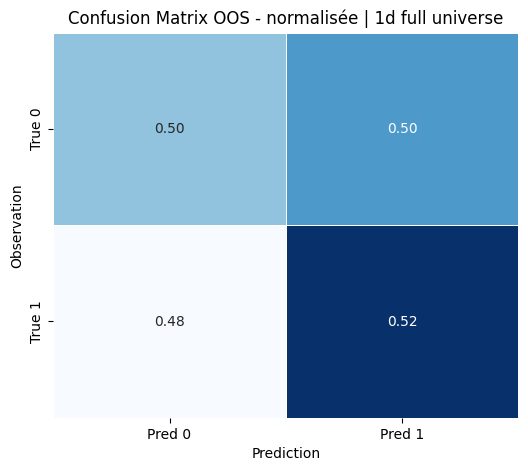

In [8]:
regression_df_all = regression_df.copy()

regression_df_1d_all = regression_df_all[regression_df_all["horizon"] == "1d"].copy()

results_all = run_penalized_logistic_rolling_backtest(
    regression_df_1d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"1d": 1},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="classical",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all["accuracy_scores"].mean())
print("F1 scores par split:", results_all["f1_scores"].tolist())
print("F1 moyen:", results_all["f1_scores"].mean())
print("ROC AUC moyen:", results_all["roc_auc_scores"].mean())
print("Log loss moyen:", results_all["log_loss_scores"].mean())

results_all_df = results_all["oos_predictions_df"]
display(results_all["fold_metrics_df"].head())
display(results_all_df.head())
print(results_all["global_metrics"])

oos_all = results_all["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 1d full universe",
)


4D

Accuracy scores par split: [0.6381066506890354, 0.6564734257903351, 0.5148975018673749, 0.6190165538612085, 0.4857764525747441, 0.34920892494929007, 0.4541944824258023, 0.7596371882086168, 0.4604857210663713, 0.5686918027782017, 0.4928277124980925, 0.31798970260508724, 0.44458714210168465, 0.5125856362096837, 0.4689457808028463, 0.5575007546030788, 0.6396369137670197, 0.5834699657176926, 0.402578159727367, 0.4775669314504266, 0.528211901093257, 0.5868698376530903, 0.47106793362643595, 0.5604440789473685, 0.4347375690607735, 0.48036295629285863, 0.5297006390850992, 0.43744114085833447, 0.6515080585835619, 0.5376020908199934, 0.521050924424262, 0.5475571890247767, 0.5931761865429824, 0.5443651198368179, 0.26141131595677053, 0.456067709919016, 0.4673375706214689, 0.49080903875424425, 0.3707593368340315, 0.510998020921685, 0.49625990845149043, 0.4679914130015963, 0.3981344307270233, 0.46511627906976744, 0.5266813671444321, 0.539044606827353, 0.46779642545771577, 0.6069864153035763, 0.48440

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,11683.0,0.497561,0.638107,0.604490,0.635327,0.676879,0.241451,88769,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,99037,1574,11609,11609.0,0.451632,0.656473,0.543498,0.616831,0.682071,0.243540,99037,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,107162,1512,12049,12049.0,0.559051,0.514898,0.546372,0.532678,0.697971,0.252342,107162,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,113136,1600,12263,12263.0,0.501019,0.619017,0.594304,0.631138,0.671699,0.239275,113136,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,118524,1598,12409,12409.0,0.516319,0.485776,0.498310,0.485048,0.709141,0.257923,118524,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,4d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.563945,0.257189,1,1,1.0,1,0.563945,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,5.0,0.6
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,4d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.550028,0.200784,1,1,1.0,1,0.550028,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,8.0,0.3
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,4d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.555715,0.223789,1,1,1.0,1,0.555715,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,7.0,0.4
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,4d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.470120,-0.119663,0,1,0.0,0,0.470120,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,10.0,0.1
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,4d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.580482,0.324750,1,1,1.0,1,0.580482,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,2.0,0.9


{'n_obs': 856863.0, 'target_rate': 0.49433806804588365, 'accuracy': 0.505863831207556, 'f1': 0.4828686271085213, 'roc_auc': 0.5056831825986106, 'log_loss': 0.697575095279302, 'brier_score': 0.25215399528915206}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 4d full universe'}, xlabel='Prediction', ylabel='Observation'>)

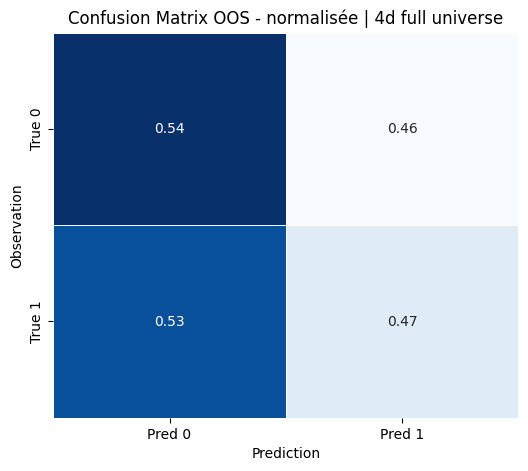

In [9]:
regression_df_all = regression_df.copy()

regression_df_4d_all = regression_df_all[regression_df_all["horizon"] == "4d"].copy()

results_all_4d = run_penalized_logistic_rolling_backtest(
    regression_df_4d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"4d": 4},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="classical",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all_4d["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all_4d["accuracy_scores"].mean())
print("F1 scores par split:", results_all_4d["f1_scores"].tolist())
print("F1 moyen:", results_all_4d["f1_scores"].mean())
print("ROC AUC moyen:", results_all_4d["roc_auc_scores"].mean())
print("Log loss moyen:", results_all_4d["log_loss_scores"].mean())

results_all_4d_df = results_all_4d["oos_predictions_df"]
display(results_all_4d["fold_metrics_df"].head())
display(results_all_4d_df.head())
print(results_all_4d["global_metrics"])

oos_all_4d = results_all_4d["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all_4d,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 4d full universe",
)


24D

Accuracy scores par split: [0.8775143370709578, 0.7429580497889569, 0.7886131629180845, 0.7266574247737095, 0.17463131598033685, 0.11594320486815415, 0.5945467706909032, 0.8624878522837707, 0.31516493948263585, 0.8081972217981988, 0.32557607202807876, 0.24175824175824176, 0.1047065044949762, 0.39250250173196827, 0.25160491917395006, 0.8286296408089345, 0.9021936459909229, 0.8660008943210613, 0.18676841013483478, 0.5717858193586349, 0.7364443466138382, 0.5863714041583594, 0.8007374840448164, 0.7535635964912281, 0.09620165745856353, 0.37743298469211056, 0.6501849983181971, 0.5061213507332167, 0.8904567645288571, 0.7421757595557007, 0.51417450535193, 0.8950636841771751, 0.5159794141940403, 0.38940591534931157, 0.11366815003178639, 0.14406624855385738, 0.5158898305084746, 0.4429223744292237, 0.45524809723287507, 0.4747526152106305, 0.5225521938148934, 0.43646960865945045, 0.4282062680595688, 0.4699239713774597, 0.4670011148272018, 0.5282657472774038, 0.5899084568439407, 0.5021722178901638,

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,11683.0,0.437388,0.877514,0.859084,0.884782,0.531353,0.171089,80954,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,91231,9380,11609,11609.0,0.469894,0.742958,0.698403,0.750497,0.612282,0.209571,91231,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,99454,9220,12049,12049.0,0.523944,0.788613,0.793213,0.795907,0.560223,0.185740,99454,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,105108,9628,12263,12263.0,0.463753,0.726657,0.697090,0.715229,0.593349,0.201496,105108,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,110281,9841,12409,12409.0,0.521154,0.174631,0.197587,0.173363,1.042901,0.413867,110281,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,24d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.564334,0.258770,1,1,1.0,1,0.564334,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,4.0,0.7
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,24d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.574891,0.301834,1,1,1.0,1,0.574891,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,3.0,0.8
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,24d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.601241,0.410638,1,1,1.0,1,0.601241,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,2.0,0.9
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,24d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.330096,-0.707752,0,1,0.0,0,0.330096,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,10.0,0.1
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,24d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.561788,0.248422,1,1,1.0,1,0.561788,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,5.0,0.6


{'n_obs': 842954.0, 'target_rate': 0.4795979377285119, 'accuracy': 0.5171171855166474, 'f1': 0.4895066481723483, 'roc_auc': 0.5170283052175585, 'log_loss': 0.7149111954614356, 'brier_score': 0.25994910120389314}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 24d full universe'}, xlabel='Prediction', ylabel='Observation'>)

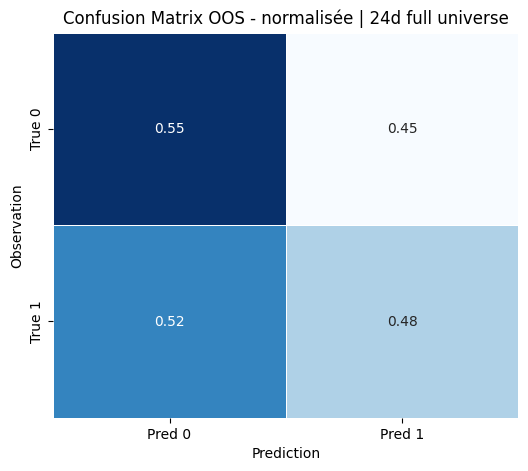

In [10]:
regression_df_all = regression_df.copy()

regression_df_24d_all = regression_df_all[regression_df_all["horizon"] == "24d"].copy()

results_all_24d = run_penalized_logistic_rolling_backtest(
    regression_df_24d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"24d": 24},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="classical",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all_24d["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all_24d["accuracy_scores"].mean())
print("F1 scores par split:", results_all_24d["f1_scores"].tolist())
print("F1 moyen:", results_all_24d["f1_scores"].mean())
print("ROC AUC moyen:", results_all_24d["roc_auc_scores"].mean())
print("Log loss moyen:", results_all_24d["log_loss_scores"].mean())

results_all_24d_df = results_all_24d["oos_predictions_df"]
display(results_all_24d["fold_metrics_df"].head())
display(results_all_24d_df.head())
print(results_all_24d["global_metrics"])

oos_all_24d = results_all_24d["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all_24d,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 24d full universe",
)


### Penalized Logistic Regression with cross sectionnal standarisation 

1D

Accuracy scores par split: [0.5546520585466062, 0.5540528899991386, 0.5060170968545108, 0.5177362798662644, 0.5085824804577322, 0.45419878296146043, 0.5196654065792649, 0.5819565921606737, 0.5210030851989558, 0.49793924591665395, 0.49816877765908746, 0.5020364251133482, 0.49278537432953085, 0.4871064583172966, 0.47536545749864645, 0.5015092061575611, 0.49296520423600604, 0.5158741988373826, 0.49488813157504813, 0.5036040011768167, 0.5280651551837993, 0.5428652805468528, 0.5150333286058715, 0.5203536184210527, 0.44765193370165746, 0.45743575535083464, 0.5549949545913219, 0.46582806403874616, 0.5312646291714037, 0.5239464227376674, 0.5023678235484917, 0.5329827007160509, 0.5380900946692928, 0.5304691483936766, 0.4062937062937063, 0.4756743591304877, 0.5137123352165726, 0.5210748155953635, 0.4127677149094342, 0.541193101498445, 0.49826950988054036, 0.5429625144492761, 0.48142677389353905, 0.5026274597495528, 0.5127342888643881, 0.48887801163865774, 0.5009808195292066, 0.4232326032714167, 

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,11683.0,0.503723,0.554652,0.595946,0.576281,0.687584,0.247220,89923,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,100221,390,11609,11609.0,0.475321,0.554053,0.571547,0.587358,0.686483,0.246683,100221,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,108279,395,12049,12049.0,0.536476,0.506017,0.534054,0.505094,0.695025,0.250920,108279,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,114329,407,12263,12263.0,0.488298,0.517736,0.534551,0.523268,0.693777,0.250305,114329,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,119734,388,12409,12409.0,0.509147,0.508582,0.523668,0.508204,0.695503,0.251163,119734,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,1d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.546009,0.184557,1,1,1.0,1,0.546009,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,5.0,0.6
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,1d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.524060,0.096315,1,1,1.0,1,0.524060,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,8.0,0.3
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,1d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.524415,0.097736,1,1,1.0,1,0.524415,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,7.0,0.4
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,1d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.475537,-0.097930,0,1,0.0,0,0.475537,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,9.0,0.2
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,1d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.559910,0.240798,1,1,1.0,1,0.559910,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,1.0,1.0


{'n_obs': 858987.0, 'target_rate': 0.49990279247532265, 'accuracy': 0.503881898096246, 'f1': 0.5246970516559689, 'roc_auc': 0.5060149855402462, 'log_loss': 0.6937590879733111, 'brier_score': 0.2503040048241172}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 1d full universe | cross-sectional scaling'}, xlabel='Prediction', ylabel='Observation'>)

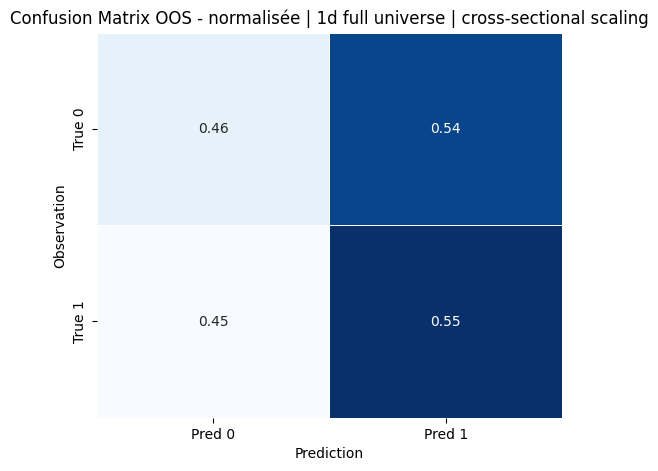

In [11]:
regression_df_all = regression_df.copy()

regression_df_1d_all = regression_df_all[regression_df_all["horizon"] == "1d"].copy()

results_all_1d_cs = run_penalized_logistic_rolling_backtest(
    regression_df_1d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"1d": 1},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="cross_sectional",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all_1d_cs["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all_1d_cs["accuracy_scores"].mean())
print("F1 scores par split:", results_all_1d_cs["f1_scores"].tolist())
print("F1 moyen:", results_all_1d_cs["f1_scores"].mean())
print("ROC AUC moyen:", results_all_1d_cs["roc_auc_scores"].mean())
print("Log loss moyen:", results_all_1d_cs["log_loss_scores"].mean())

results_all_1d_cs_df = results_all_1d_cs["oos_predictions_df"]
display(results_all_1d_cs["fold_metrics_df"].head())
display(results_all_1d_cs_df.head())
print(results_all_1d_cs["global_metrics"])

oos_all_1d_cs = results_all_1d_cs["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all_1d_cs,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 1d full universe | cross-sectional scaling",
)


4D

Accuracy scores par split: [0.6371651117007618, 0.67430441898527, 0.5159764295792182, 0.6075185517410095, 0.48964461278104604, 0.3538336713995943, 0.42676747365881124, 0.7213313896987367, 0.47306383988608497, 0.5579300870096169, 0.49427743018464826, 0.3323599477445631, 0.43121553222029163, 0.47240397198060197, 0.49091190347281305, 0.4913975249019016, 0.6324508320726172, 0.6593382024146669, 0.36027559638464957, 0.45616357752280084, 0.5420060165822878, 0.5905012816861293, 0.47631541625301377, 0.5687362938596491, 0.387707182320442, 0.47606843527048553, 0.539724184325597, 0.39734965693528856, 0.679462315254464, 0.5813786344331918, 0.42795977943561464, 0.5773398390469552, 0.619861490564839, 0.530086690464049, 0.2491417673235855, 0.4253181513730743, 0.4948799435028249, 0.49976583538227376, 0.27724349519145675, 0.47435679954763926, 0.4604778385620185, 0.4905047613805251, 0.4462551440329218, 0.4879807692307692, 0.497574421168688, 0.5191951139709892, 0.4719921534437663, 0.5260327141668977, 0.47

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,11683.0,0.497561,0.637165,0.630202,0.657408,0.673852,0.240372,88769,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,99037,1574,11609,11609.0,0.451632,0.674304,0.628695,0.689001,0.666230,0.236619,99037,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,107162,1512,12049,12049.0,0.559051,0.515976,0.549653,0.522358,0.697246,0.251981,107162,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,113136,1600,12263,12263.0,0.501019,0.607519,0.589789,0.604252,0.675935,0.241410,113136,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,118524,1598,12409,12409.0,0.516319,0.489645,0.503567,0.492866,0.708348,0.257412,118524,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,4d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.559620,0.239621,1,1,1.0,1,0.559620,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,3.0,0.8
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,4d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.541818,0.167662,1,1,1.0,1,0.541818,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,8.0,0.3
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,4d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.548608,0.195050,1,1,1.0,1,0.548608,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,6.0,0.5
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,4d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.458893,-0.164800,0,1,0.0,0,0.458893,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,10.0,0.1
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,4d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.572890,0.293652,1,1,1.0,1,0.572890,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,2.0,0.9


{'n_obs': 856863.0, 'target_rate': 0.49433806804588365, 'accuracy': 0.4983422087311507, 'f1': 0.4555623950330195, 'roc_auc': 0.49865684807742067, 'log_loss': 0.6959235444684897, 'brier_score': 0.2513710188450822}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 4d full universe | cross-sectional scaling'}, xlabel='Prediction', ylabel='Observation'>)

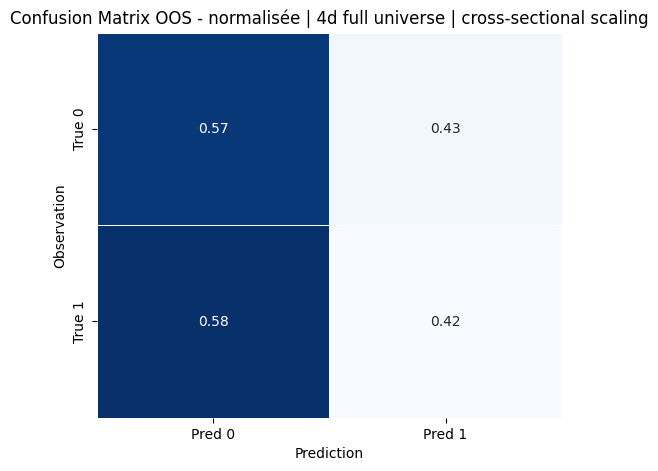

In [12]:
regression_df_all = regression_df.copy()

regression_df_4d_all = regression_df_all[regression_df_all["horizon"] == "4d"].copy()

results_all_4d_cs = run_penalized_logistic_rolling_backtest(
    regression_df_4d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"4d": 4},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="cross_sectional",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all_4d_cs["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all_4d_cs["accuracy_scores"].mean())
print("F1 scores par split:", results_all_4d_cs["f1_scores"].tolist())
print("F1 moyen:", results_all_4d_cs["f1_scores"].mean())
print("ROC AUC moyen:", results_all_4d_cs["roc_auc_scores"].mean())
print("Log loss moyen:", results_all_4d_cs["log_loss_scores"].mean())

results_all_4d_cs_df = results_all_4d_cs["oos_predictions_df"]
display(results_all_4d_cs["fold_metrics_df"].head())
display(results_all_4d_cs_df.head())
print(results_all_4d_cs["global_metrics"])

oos_all_4d_cs = results_all_4d_cs["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all_4d_cs,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 4d full universe | cross-sectional scaling",
)


24D

Accuracy scores par split: [0.8961739279294701, 0.7522611766732707, 0.7989874678396548, 0.7268205170023648, 0.17463131598033685, 0.12113590263691684, 0.587468832944583, 0.8189180434078394, 0.31785460011075073, 0.7877423294153564, 0.32290553944758127, 0.23514946591869668, 0.1396842184785072, 0.4358401970595027, 0.25493077577538864, 0.7536220947781467, 0.8925869894099848, 0.8624981368311224, 0.1800266706178693, 0.5218446601941747, 0.7298407806882383, 0.5857305610937055, 0.8039285207771947, 0.7548656798245614, 0.09668508287292818, 0.38429036503428693, 0.6411705348133199, 0.5059868155522669, 0.8791546846786598, 0.7362953283240771, 0.3586117418099254, 0.8981686838603384, 0.6759006290107377, 0.3836053034166242, 0.13452002542911634, 0.1557571698228095, 0.535958097928437, 0.40908558716777893, 0.44492300430703874, 0.4858919988690981, 0.4909009713073574, 0.4151540383014155, 0.4738275172260502, 0.4251453488372093, 0.4195094760312152, 0.5310020248454003, 0.5740518744551003, 0.40269577809958784, 0.

,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,11683.0,0.437388,0.896174,0.880622,0.892157,0.532976,0.171794,80954,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,91231,9380,11609,11609.0,0.469894,0.752261,0.706171,0.773549,0.600567,0.204491,91231,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,99454,9220,12049,12049.0,0.523944,0.798987,0.806364,0.799829,0.554693,0.182840,99454,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,105108,9628,12263,12263.0,0.463753,0.726821,0.697326,0.702681,0.611891,0.209068,105108,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,110281,9841,12409,12409.0,0.521154,0.174631,0.197587,0.161973,1.027321,0.405415,110281,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,rank_pred_proba,rank_pct_pred_proba
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,24d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.597889,0.396678,1,1,1.0,1,0.597889,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,4.0,0.7
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,24d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.602791,0.417109,1,1,1.0,1,0.602791,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,3.0,0.8
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,24d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.633401,0.546834,1,1,1.0,1,0.633401,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,2.0,0.9
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,24d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.351490,-0.612496,0,1,0.0,0,0.351490,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,10.0,0.1
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,24d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.592145,0.372839,1,1,1.0,1,0.592145,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,5.0,0.6


{'n_obs': 842954.0, 'target_rate': 0.4795979377285119, 'accuracy': 0.5130718876712134, 'f1': 0.4501832463538262, 'roc_auc': 0.5163364097329745, 'log_loss': 0.7074894444151761, 'brier_score': 0.25632714367447806}


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Confusion Matrix OOS - normalisée | 24d full universe | cross-sectional scaling'}, xlabel='Prediction', ylabel='Observation'>)

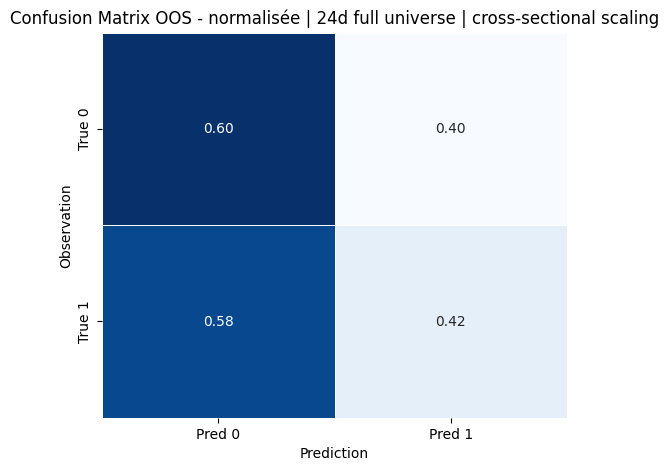

In [13]:
regression_df_all = regression_df.copy()

regression_df_24d_all = regression_df_all[regression_df_all["horizon"] == "24d"].copy()

results_all_24d_cs = run_penalized_logistic_rolling_backtest(
    regression_df_24d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"24d": 24},
    period_train=365,
    period_test=30,
    period_embargo=5,
    penalty_type="l2",
    C=0.05,
    max_iter=3000,
    scaling_mode="cross_sectional",
    include_horizon=False,
    filter_active_only=True,
    verbose=0,
)

print("Accuracy scores par split:", results_all_24d_cs["accuracy_scores"].tolist())
print("Accuracy moyen:", results_all_24d_cs["accuracy_scores"].mean())
print("F1 scores par split:", results_all_24d_cs["f1_scores"].tolist())
print("F1 moyen:", results_all_24d_cs["f1_scores"].mean())
print("ROC AUC moyen:", results_all_24d_cs["roc_auc_scores"].mean())
print("Log loss moyen:", results_all_24d_cs["log_loss_scores"].mean())

results_all_24d_cs_df = results_all_24d_cs["oos_predictions_df"]
display(results_all_24d_cs["fold_metrics_df"].head())
display(results_all_24d_cs_df.head())
print(results_all_24d_cs["global_metrics"])

oos_all_24d_cs = results_all_24d_cs["oos_predictions_df"].copy()

plot_confusion_matrix_for_backtest(
    results_all_24d_cs,
    normalize="true",
    title="Confusion Matrix OOS - normalisée | 24d full universe | cross-sectional scaling",
)


### Interpretation of the logistic regression under both scaling choices

Taken together, the two scaling approaches show that the penalized logistic regression does capture a **real, albeit modest, predictive structure**. The model is not strong enough to be presented as a high-performance classifier, but it does provide a **coherent first benchmark** and a useful basis for indicator ranking.

 Main takeaway

Across both preprocessing choices, the results support three encouraging conclusions:

1. **The model is not purely random.**  
   ROC AUC remains slightly above 0.5 across all horizons, which suggests that the features contain some exploitable information.

2. **The horizon split is clearly justified.**  
   The behavior of the model changes across `1d`, `4d`, and `24d`, which confirms that indicator usefulness is horizon-dependent.

3. **The logistic regression is useful as a benchmark and ranking tool.**  
   Even when classification performance remains limited, the model still produces probabilities that can be used to order indicators within each `date × asset × horizon` decision set.

---

   Comparison of the two scaling approaches

    Classical scaling

Classical scaling delivers the **strongest overall discrimination**.  
It tends to produce slightly better ROC AUC across the three horizons and remains the most solid choice if the objective is to maximize the global predictive quality of the logistic benchmark.

Its main strength is stability: it gives the cleanest overall baseline and performs relatively better at the medium and long horizons.

   Cross-sectional scaling

Cross-sectional scaling is **more aligned with the logic of the project**, since the decision problem is fundamentally cross-sectional: at a given date, the goal is to compare indicators across assets rather than model absolute levels in isolation.

Empirically, this scaling does not dominate the classical version, but it remains interesting because:
- it is more consistent with the ranking objective,
- it improves the short-horizon classification balance,
- and it gives the best short-horizon F1 score among the two approaches.

So even if it is not uniformly better, it is methodologically attractive, especially for the short-term use case.

---

   Horizon-by-horizon interpretation

    1d horizon

This is the most promising horizon overall.

- With **classical scaling**, the model achieves slightly better discrimination.
- With **cross-sectional scaling**, the model achieves a better F1 and a more active detection of positives.

This suggests that at short horizon, the signal is weak but present, and the model is already capable of producing a ranking that is at least directionally informative. In practice, `1d` appears to be the horizon where the logistic regression is most naturally usable as a first ranking layer.

    4d horizon

This is the least convincing horizon.

The model remains above pure randomness, but only marginally. Both versions struggle here, and cross-sectional scaling does not improve the results. This suggests that the intermediate horizon is more difficult to capture with a linear model, likely because the relationship between signals and outcomes becomes less direct and more conditional on market context.

   24d horizon

This horizon is the most unstable but also the most interesting conceptually.

The classical version gives the best average AUC among the three horizons, which indicates that some longer-term structure may be present. At the same time, fold-to-fold variation remains large, which means that this structure is not stable through time.

So the `24d` model cannot yet be considered reliable, but it does suggest that longer-horizon signal usefulness may exist in certain regimes and deserves further investigation.

---

    What is encouraging in the project context

Even without overstating the results, the model already provides several useful contributions:

- it confirms that **indicator effectiveness is horizon-specific**,
- it delivers a **transparent and interpretable baseline**,
- it generates a **probability of success**, not just a binary class,
- and this probability can already be used to **rank indicators** for a given asset, date, and horizon.

This last point is important: in the context of the project, the value of the model is not only in raw classification performance, but also in its ability to structure the decision process and highlight the most promising indicators.

---

    Main limitations

The limitations remain clear and should be stated explicitly:

- discrimination remains weak overall,
- probability quality is still limited,
- performance varies substantially across folds,
- and a linear model is likely too restrictive to capture all relevant interactions between signals, families, contexts, and horizons.

In other words, this logistic regression should be seen as a **useful baseline**, not as a final model.

---

    Balanced conclusion

The results are modest, but they are still meaningful.  
They show that the pipeline is capturing a small amount of genuine structure and that the modeling framework is directionally sound.

A fair conclusion is therefore:

- **classical scaling gives the strongest overall benchmark**,  
- **cross-sectional scaling is the most conceptually aligned with the project**, especially at `1d`,  
- and the logistic regression already serves as a credible first model for **probability-based ranking of indicators**, even if stronger nonlinear models will likely be needed to unlock more predictive power.

## Random Forest 

This section runs the Random Forest benchmark separately on the three prediction horizons:
- `1d`
- `4d`
- `24d`

Each run uses the same final regression dataset, filtered to one horizon at a time, and applies the same rolling-window backtest with a `365`-day training window, a `30`-day test window, and a `5`-day embargo. This keeps the evaluation protocol fully comparable across horizons and with the logistic regression benchmark.

The Random Forest is specified as a moderately regularized non-linear model:
- `n_estimators = 400`
- `max_depth = 6`
- `min_samples_leaf = 20`
- `max_features = "sqrt"`
- `class_weight = "balanced"`

This setup allows the model to capture non-linear patterns and feature interactions while controlling tree complexity and reducing the risk of overfitting.

For each horizon, the backtest returns three main outputs:
- `global_metrics`, which summarize aggregate out-of-sample performance over the full rolling evaluation
- `fold_metrics_df`, which reports fold-by-fold results and allows performance stability to be assessed through time
- `oos_predictions_df`, which contains row-level out-of-sample predictions, including `pred_proba_success`, `pred_class`, and the ranking variables used to compare indicators within each `date × asset × horizon` group

As with the logistic regression, the key output is the estimated probability of success. This is what allows the Random Forest to be used not only as a classifier, but also as a ranking model for identifying the most promising indicators at each decision point.


In [ ]:
rf_results = run_random_forest_rolling_backtest(
    regression_df_1d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",                    
    horizon_steps_map={"1d": 1},
    period_train=365,
    period_test=30,
    period_embargo=5,
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    filter_active_only=True,
    verbose=0,
)

print(rf_results["global_metrics"])
display(rf_results["fold_metrics_df"].head())
display(rf_results["oos_predictions_df"].head())

{'n_obs': 858987.0, 'target_rate': 0.49990279247532265, 'accuracy': 0.510942540457539, 'f1': 0.4954625813084292, 'roc_auc': 0.5159755764213562, 'log_loss': 0.6928499886962746, 'brier_score': 0.24984885099524107}


,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683,11683.0,0.503723,0.563383,0.528515,0.580122,0.687775,0.247326,89923,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,100221,390,11609,11609.0,0.475321,0.545008,0.419943,0.560351,0.689091,0.247977,100221,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,108279,395,12049,12049.0,0.536476,0.484356,0.472446,0.503810,0.693508,0.250182,108279,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,114329,407,12263,12263.0,0.488298,0.540651,0.437207,0.540247,0.690722,0.248790,114329,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,119734,388,12409,12409.0,0.509147,0.504150,0.494454,0.505830,0.697188,0.251984,119734,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,rank_pred_proba,rank_pct_pred_proba,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,1d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.557985,0.232990,1,1.0,1.0,1,1.0,1,0.557985,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,1d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.550983,0.204642,1,2.0,0.9,1,1.0,1,0.550983,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,1d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.550570,0.202972,1,3.0,0.8,1,1.0,1,0.550570,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,1d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.497284,-0.010865,0,9.0,0.2,1,0.0,0,0.497284,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,1d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.547724,0.191480,1,5.0,0.6,1,1.0,1,0.547724,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,89923,382,11683


In [15]:
rf_results = run_random_forest_rolling_backtest(
    regression_df_4d_all,
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"4d": 4},
    period_train=365,
    period_test=30,
    period_embargo=5,
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    filter_active_only=True,
    verbose=0,
)

print(rf_results["global_metrics"])
display(rf_results["fold_metrics_df"].head())
display(rf_results["oos_predictions_df"].head())

{'n_obs': 856863.0, 'target_rate': 0.49433806804588365, 'accuracy': 0.5099461640892418, 'f1': 0.4996800833094041, 'roc_auc': 0.5085441894743604, 'log_loss': 0.6948558363251087, 'brier_score': 0.2508414642888444}


,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683,11683.0,0.497561,0.584525,0.551220,0.598502,0.687913,0.247381,88769,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,99037,1574,11609,11609.0,0.451632,0.683263,0.601582,0.697061,0.671406,0.239256,99037,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,107162,1512,12049,12049.0,0.559051,0.515727,0.552222,0.526570,0.692936,0.249887,107162,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,113136,1600,12263,12263.0,0.501019,0.619424,0.586369,0.638030,0.678702,0.242780,113136,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,118524,1598,12409,12409.0,0.516319,0.487872,0.502232,0.486262,0.704237,0.255422,118524,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,rank_pred_proba,rank_pct_pred_proba,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,4d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.543107,0.172857,1,1.0,1.0,1,1.0,1,0.543107,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,4d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.533966,0.136072,1,2.0,0.9,1,1.0,1,0.533966,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,4d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.531903,0.127787,1,5.0,0.6,1,1.0,1,0.531903,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,4d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.484836,-0.060675,0,10.0,0.1,1,0.0,0,0.484836,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,4d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.531176,0.124868,1,7.0,0.4,1,1.0,1,0.531176,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,88769,1536,11683


In [16]:
rf_results = run_random_forest_rolling_backtest(
    regression_df_24d_all,  
    datetime_col="date",
    asset_col="asset",
    indicator_col="indicator_name",
    family_col="signal_family",
    horizon_col="horizon",
    target_col="target",
    horizon_steps_map={"24d": 24},
    period_train=365,
    period_test=30,
    period_embargo=5,
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    filter_active_only=True,
    verbose=0,
)

print(rf_results["global_metrics"])
display(rf_results["fold_metrics_df"].head())
display(rf_results["oos_predictions_df"].head())

{'n_obs': 842954.0, 'target_rate': 0.4795979377285119, 'accuracy': 0.5154765265957573, 'f1': 0.5089385871153053, 'roc_auc': 0.515056651324849, 'log_loss': 0.704798496207847, 'brier_score': 0.25544595862340397}


,fold_id,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows,n_obs,target_rate,accuracy,f1,roc_auc,log_loss,brier_score,n_train_used_for_fit,n_test_scored
0,1,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683,11683.0,0.437388,0.883249,0.860646,0.883935,0.593529,0.200797,80954,11683
1,2,2020-01-18,2021-01-16,2021-01-22,2021-02-20,365,30,5,100611,91231,9380,11609,11609.0,0.469894,0.734086,0.675565,0.761890,0.622840,0.216174,91231,11609
2,3,2020-02-17,2021-02-15,2021-02-21,2021-03-22,365,30,5,108674,99454,9220,12049,12049.0,0.523944,0.799485,0.806410,0.805121,0.602512,0.205426,99454,12049
3,4,2020-03-18,2021-03-17,2021-03-23,2021-04-21,365,30,5,114736,105108,9628,12263,12263.0,0.463753,0.726005,0.696477,0.708917,0.629849,0.217838,105108,12263
4,5,2020-04-17,2021-04-16,2021-04-22,2021-05-21,365,30,5,120122,110281,9841,12409,12409.0,0.521154,0.176243,0.202403,0.165684,0.915211,0.355449,110281,12409


,date,asset,indicator_name,signal_family,horizon,signal_direction,signal_active,signal_strength,signal_signed_value,target,hlc_average,median_price,ohlc_average,atr_14,natr_14,adx_14,plus_di_14,minus_di_14,dx_14,choppiness_14,entropy_20,kurtosis_20,mass_index_9_25,mad_close_20,midpoint_14,midprice_14,price_distance_sma_20,price_distance_ref_sma_20,quantile_rank_20,pred_proba_success,pred_log_odds,pred_class,rank_pred_proba,rank_pct_pred_proba,fold_id,y_true,y_pred,y_proba_pred,train_start,train_end,test_start,test_end,period_train,period_test,period_embargo,n_train_rows_raw,n_train_rows_after_purge,n_train_rows_purged,n_test_rows
0,2020-12-23,AAVEUSDT,cci_20,extreme_zone_oscillator,24d,1.0,1.0,163.260223,0.573046,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.523508,0.094102,1,2.0,0.9,1,1.0,1,0.523508,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683
1,2020-12-23,AAVEUSDT,cog_10,extreme_zone_oscillator,24d,1.0,1.0,5.589016,0.339294,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.522369,0.089535,1,3.0,0.8,1,1.0,1,0.522369,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683
2,2020-12-23,AAVEUSDT,emotion_index_14,extreme_zone_oscillator,24d,1.0,1.0,14.137884,1.078563,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.532003,0.128189,1,1.0,1.0,1,1.0,1,0.532003,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683
3,2020-12-23,AAVEUSDT,mfi_14,extreme_zone_oscillator,24d,-1.0,1.0,3.014785,0.289813,0.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.452535,-0.190432,0,10.0,0.1,1,0.0,0,0.452535,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683
4,2020-12-23,AAVEUSDT,pgo_14,extreme_zone_oscillator,24d,1.0,1.0,0.748494,-0.230918,1.0,74.239,73.643,76.76625,10.430469,0.138278,18.739015,14.778405,25.851574,27.253692,51.397687,0.63093,-0.055124,24.331642,4.3171,82.6135,79.6055,-0.102247,84.022,0.1,0.518991,0.076001,1,6.0,0.5,1,1.0,1,0.518991,2019-12-19,2020-12-17,2020-12-23,2021-01-21,365,30,5,90305,80954,9351,11683


Interprétation des résultats globaux par horizon

Les résultats montrent que le modèle capte un **signal faible mais réel** sur les trois horizons, sans pour autant atteindre un niveau de performance élevé. 

    Horizon 1d

Pour `1d`, les métriques sont :

- `n_obs = 858987`
- `target_rate = 0.4999`
- `accuracy = 0.5109`
- `f1 = 0.4955`
- `roc_auc = 0.5160`
- `log_loss = 0.6928`
- `brier_score = 0.2498`

La target est presque parfaitement équilibrée, ce qui rend le problème difficile à battre nettement avec une baseline simple. Le `ROC AUC` légèrement supérieur à `0.5` montre que le modèle ne se réduit pas à du hasard pur : il y a bien un peu d’information exploitable. En revanche, l’`accuracy` et le `F1` restent modestes, ce qui signifie que la séparation entre succès et échec reste faible. Le `log loss` et le `Brier score`, très proches de leurs niveaux non informatifs, indiquent aussi que les probabilités produites restent peu tranchées. Malgré cela, `1d` reste l’horizon le plus naturel pour une utilisation du modèle comme **outil de ranking court terme**.

    Horizon 4d

Pour `4d`, les métriques sont :

- `n_obs = 856863`
- `target_rate = 0.4943`
- `accuracy = 0.5099`
- `f1 = 0.4997`
- `roc_auc = 0.5085`
- `log_loss = 0.6949`
- `brier_score = 0.2508`

C’est l’horizon le moins convaincant. Le `ROC AUC` retombe presque exactement au niveau du hasard, ce qui suggère que le modèle distingue très peu les bons et mauvais cas à cet horizon. L’`accuracy` et le `F1` restent autour de `0.50`, donc le modèle ne s’effondre pas totalement, mais il ne fournit pas non plus de vraie puissance prédictive. Le `log loss` et le `Brier score` sont légèrement plus mauvais que pour `1d`, ce qui montre que les probabilités sont encore moins informatives. En pratique, cela suggère que l’horizon intermédiaire est probablement le plus difficile à modéliser avec un modèle de ce type.

    Horizon 24d

Pour `24d`, les métriques sont :

- `n_obs = 842954`
- `target_rate = 0.4796`
- `accuracy = 0.5155`
- `f1 = 0.5089`
- `roc_auc = 0.5151`
- `log_loss = 0.7048`
- `brier_score = 0.2554`

À `24d`, l’`accuracy` et le `F1` sont légèrement supérieurs à ceux des deux autres horizons, ce qui peut donner l’impression d’une amélioration. Toutefois, cette lecture doit être nuancée : le `ROC AUC` reste faible, donc la capacité de discrimination demeure limitée. Surtout, le `log loss` et le `Brier score` sont les plus mauvais des trois horizons, ce qui montre que les probabilités sont moins bien calibrées et moins fiables à long horizon. Autrement dit, le modèle peut parfois mieux classer certaines observations, mais il reste globalement peu sûr dans ses scores.

    Lecture d’ensemble

Pris ensemble, ces résultats suggèrent plusieurs points importants :

- le modèle est **légèrement meilleur que le hasard**, mais seulement de façon marginale ;
- `1d` semble être l’horizon le plus exploitable dans une logique de **ranking court terme** ;
- `4d` est l’horizon le plus faible ;
- `24d` montre un peu plus de structure en classification, mais avec des probabilités plus dégradées.

Dans le cadre du projet, cela reste intéressant, car l’objectif principal n’est pas seulement de prédire une classe 0/1, mais surtout de produire une **probabilité de succès** pour ensuite **classer les indicateurs** par `date × asset × horizon`. Sous cet angle, même un modèle globalement modeste peut déjà fournir une information utile s’il permet d’ordonner les signaux de façon un peu meilleure que le hasard.

    Conclusion

Ces résultats ne valident pas encore un modèle prédictif fort. En revanche, ils montrent que :

- le pipeline apprend quelque chose ;
- les trois horizons doivent bien être traités séparément ;
- et le modèle peut déjà servir de **benchmark interprétable** et de **mécanisme de ranking**.